# Machine Learning in Particle Physics (Supervised Learning)

iSTEP 2025, instructor Congqiao Li (PKU, licongqiao@pku.edu.cn)

In this notebook, we will do a hands-on session on supervised learning. This Jupyter notebook is designed to be used together with the slides, so please refer to both.

Course Indico link: https://indico.ihep.ac.cn/event/26065/timetable/?view=standard#b-19113

This notebook is also available on [GitHub](https://github.com/colizz/ml-tutorial/blob/v2025-08-istep/iSTEP_SupervisedLearning_HandsOn.ipynb).

## Background of this hands-on session

In the slides, we have introduced the history of supervised learning. In fact, the field of high energy physics started using machine learning, including early "artificial neural networks", for event classification as early as 30-40 years ago—making it one of the earliest scientific fields to adopt these techniques. The discovery of the Higgs boson in 2012 also relied heavily on machine learning to identify its special decay processes.

The discovery of the Higgs boson in 2012 completed the last missing piece of the Standard Model and was a milestone in particle physics experiments. One of the main goals of the upcoming High-Luminosity LHC experiments is to study the self-coupling property of the Higgs boson. In the Standard Model, after electroweak symmetry breaking, the Lagrangian includes terms where Higgs bosons couple to themselves. This leads to physical processes where three or four Higgs bosons interact directly. A typical example is shown in the Feynman diagram below, which illustrates one way that two Higgs bosons can be produced together.

<img src="figures/DihiggsFD.jpg" alt="Drawing" width=300/>

In this process, because of the Higgs self-coupling, two Higgs bosons are produced in the final state. If we can measure the cross section of this process, we can set limits on the self-coupling modifier $\kappa_\lambda$. Here, we focus on a special decay mode: one Higgs decays to $b\bar{b}$ (the most common decay), and the other decays to $W^+W^-$. In this example, we will use reconstructed event information to distinguish the double Higgs signal process $HH\to b\bar{b}W^+W^-$ from its main background process $t\bar{t}\to b\bar{b}W^+W^-$. The signal and background have the following features:
 - Both processes have exactly the same final state particles: two b quarks form two b-jets; the two W bosons decay leptonically, producing two leptons (electrons or muons) and invisible neutrinos.
 - However, the kinematics of the final state particles are slightly different: in $HH$ and $t\bar{t}$, the particles are produced back-to-back (due to high relativistic effects), but in $HH$ the two b-jets and two W bosons tend to be close to each other, while in $t\bar{t}$ each b-jet and W boson pair tends to be close.
 - Experimentally, we can measure the final state information for both signal and background, i.e. the two b-jets and two leptons (their four-momenta, jet properties, etc.).

So, can we use machine learning techniques to distinguish these two processes using the reconstructed event information?

<img src="figures/SigBkgFS.png" alt="Drawing" width=700/>

> Notes on event reconstruction information:
>
> - First, at the LHC, quarks (such as b quarks) and gluons will eventually form jets—these are narrow cones of particles with high energy, clustered within a certain radius. The strong interaction is weaker at high energies but becomes very strong at low energies. Because of color confinement, quarks cannot exist alone and must combine with other quarks to form hadrons. As a result, quarks undergo hadronization and parton showering, and what we finally observe is a jet—a spray of hadrons.
> - Second, neutrinos cannot be directly detected by the detector. However, since they carry away some transverse momentum, they break the conservation of momentum in the transverse plane. By reconstructing the missing transverse momentum and its direction, we can infer the presence of neutrinos in the event.


## Introduction to the dataset

Our dataset contains examples of both the signal and background physics processes described above.

The stored features include two b-jets formed from b quarks (`bjet1_*`, `bjet2_*` features), two leptons (`lep1_*`, `lep2_*` features), and missing transverse momentum (`met_*` features). Below, we use the `pandas` data analysis package to display the stored data in a table.


In [ ]:
! mkdir -p data
! if [ ! -f data/hh2b2w.root ] || [ ! -f data/ttbar.root ]; then \
    wget -O data/hh2b2w.root https://coli.web.cern.ch/coli/share/cmschina/ML/dihiggs_ntuples/hh2b2w.root; \
    wget -O data/ttbar.root https://coli.web.cern.ch/coli/share/cmschina/ML/dihiggs_ntuples/ttbar.root; \
fi

In [2]:
import os
import uproot
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load signal (di-Higgs) and background (ttbar) events from ROOT file into a pandas DataFrame
dihiggs = uproot.concatenate(f"./data/hh2b2w.root:tree", library="pd")
ttbar = uproot.concatenate(f"./data/ttbar.root:tree", library="pd")

# Concatenate signal and background DataFrames into a single DataFrame
df_raw = pd.concat([dihiggs, ttbar], axis=0)

# Create a new column 'label': 1 for signal, 0 for background (convert boolean to int)
df_raw['label'] = df_raw['is_sig'].astype(int)

# Display the combined DataFrame
df_raw

,event,is_sig,is_bkg,bjet1_pt,bjet1_eta,bjet1_phi,bjet1_eratio,bjet1_mass,bjet1_ncharged,bjet1_nneutrals,...,lep1_charge,lep1_type,lep2_pt,lep2_phi,lep2_eta,lep2_charge,lep2_type,met,met_phi,label
0,0,True,False,191.402328,-0.291164,-0.979666,0.289940,16.695002,12,6,...,1,0,17.508558,1.165262,-0.711694,-1,0,233.613846,2.300718,1
1,1,True,False,68.452507,-1.215415,2.387005,0.492361,15.253864,10,10,...,1,1,50.567219,-1.089323,0.409210,-1,1,102.682526,-0.004101,1
2,2,True,False,152.725433,0.449958,-1.470235,1.215402,12.211457,12,8,...,1,1,43.384056,0.584961,0.624317,-1,0,57.796436,0.935978,1
3,3,True,False,107.360390,0.124028,-1.175005,0.000000,6.060685,6,4,...,1,1,26.664654,2.175398,0.556468,-1,1,65.674774,1.417736,1
4,4,True,False,97.040932,2.160315,-2.940341,0.000000,10.475123,10,14,...,-1,1,29.825296,0.306789,0.310836,1,0,94.994255,-3.043913,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149995,False,True,169.980515,-0.147777,2.985398,0.209411,27.176857,12,8,...,-1,1,92.388741,-0.697610,0.483596,1,1,131.839859,-0.000835,0
149996,149996,False,True,47.205002,1.002193,-1.613720,0.000000,9.505911,10,8,...,-1,0,62.515564,0.693190,0.890577,1,0,75.465065,1.878048,0
149997,149997,False,True,63.940311,0.381228,0.494209,0.166411,8.920477,10,8,...,1,0,34.591877,2.737549,-0.180914,-1,1,59.409447,0.176429,0
149998,149998,False,True,89.012772,-0.562279,-0.638000,0.648749,13.602261,11,12,...,-1,1,20.882822,-3.140386,-1.086141,1,0,44.600636,-1.177096,0


Let's use what we learned in the previous session to plot histograms for each feature and look at their basic distributions.

> We can see that if we only look at the kinematic information of the final-state leptons and jets, it is difficult to distinguish between the two processes.

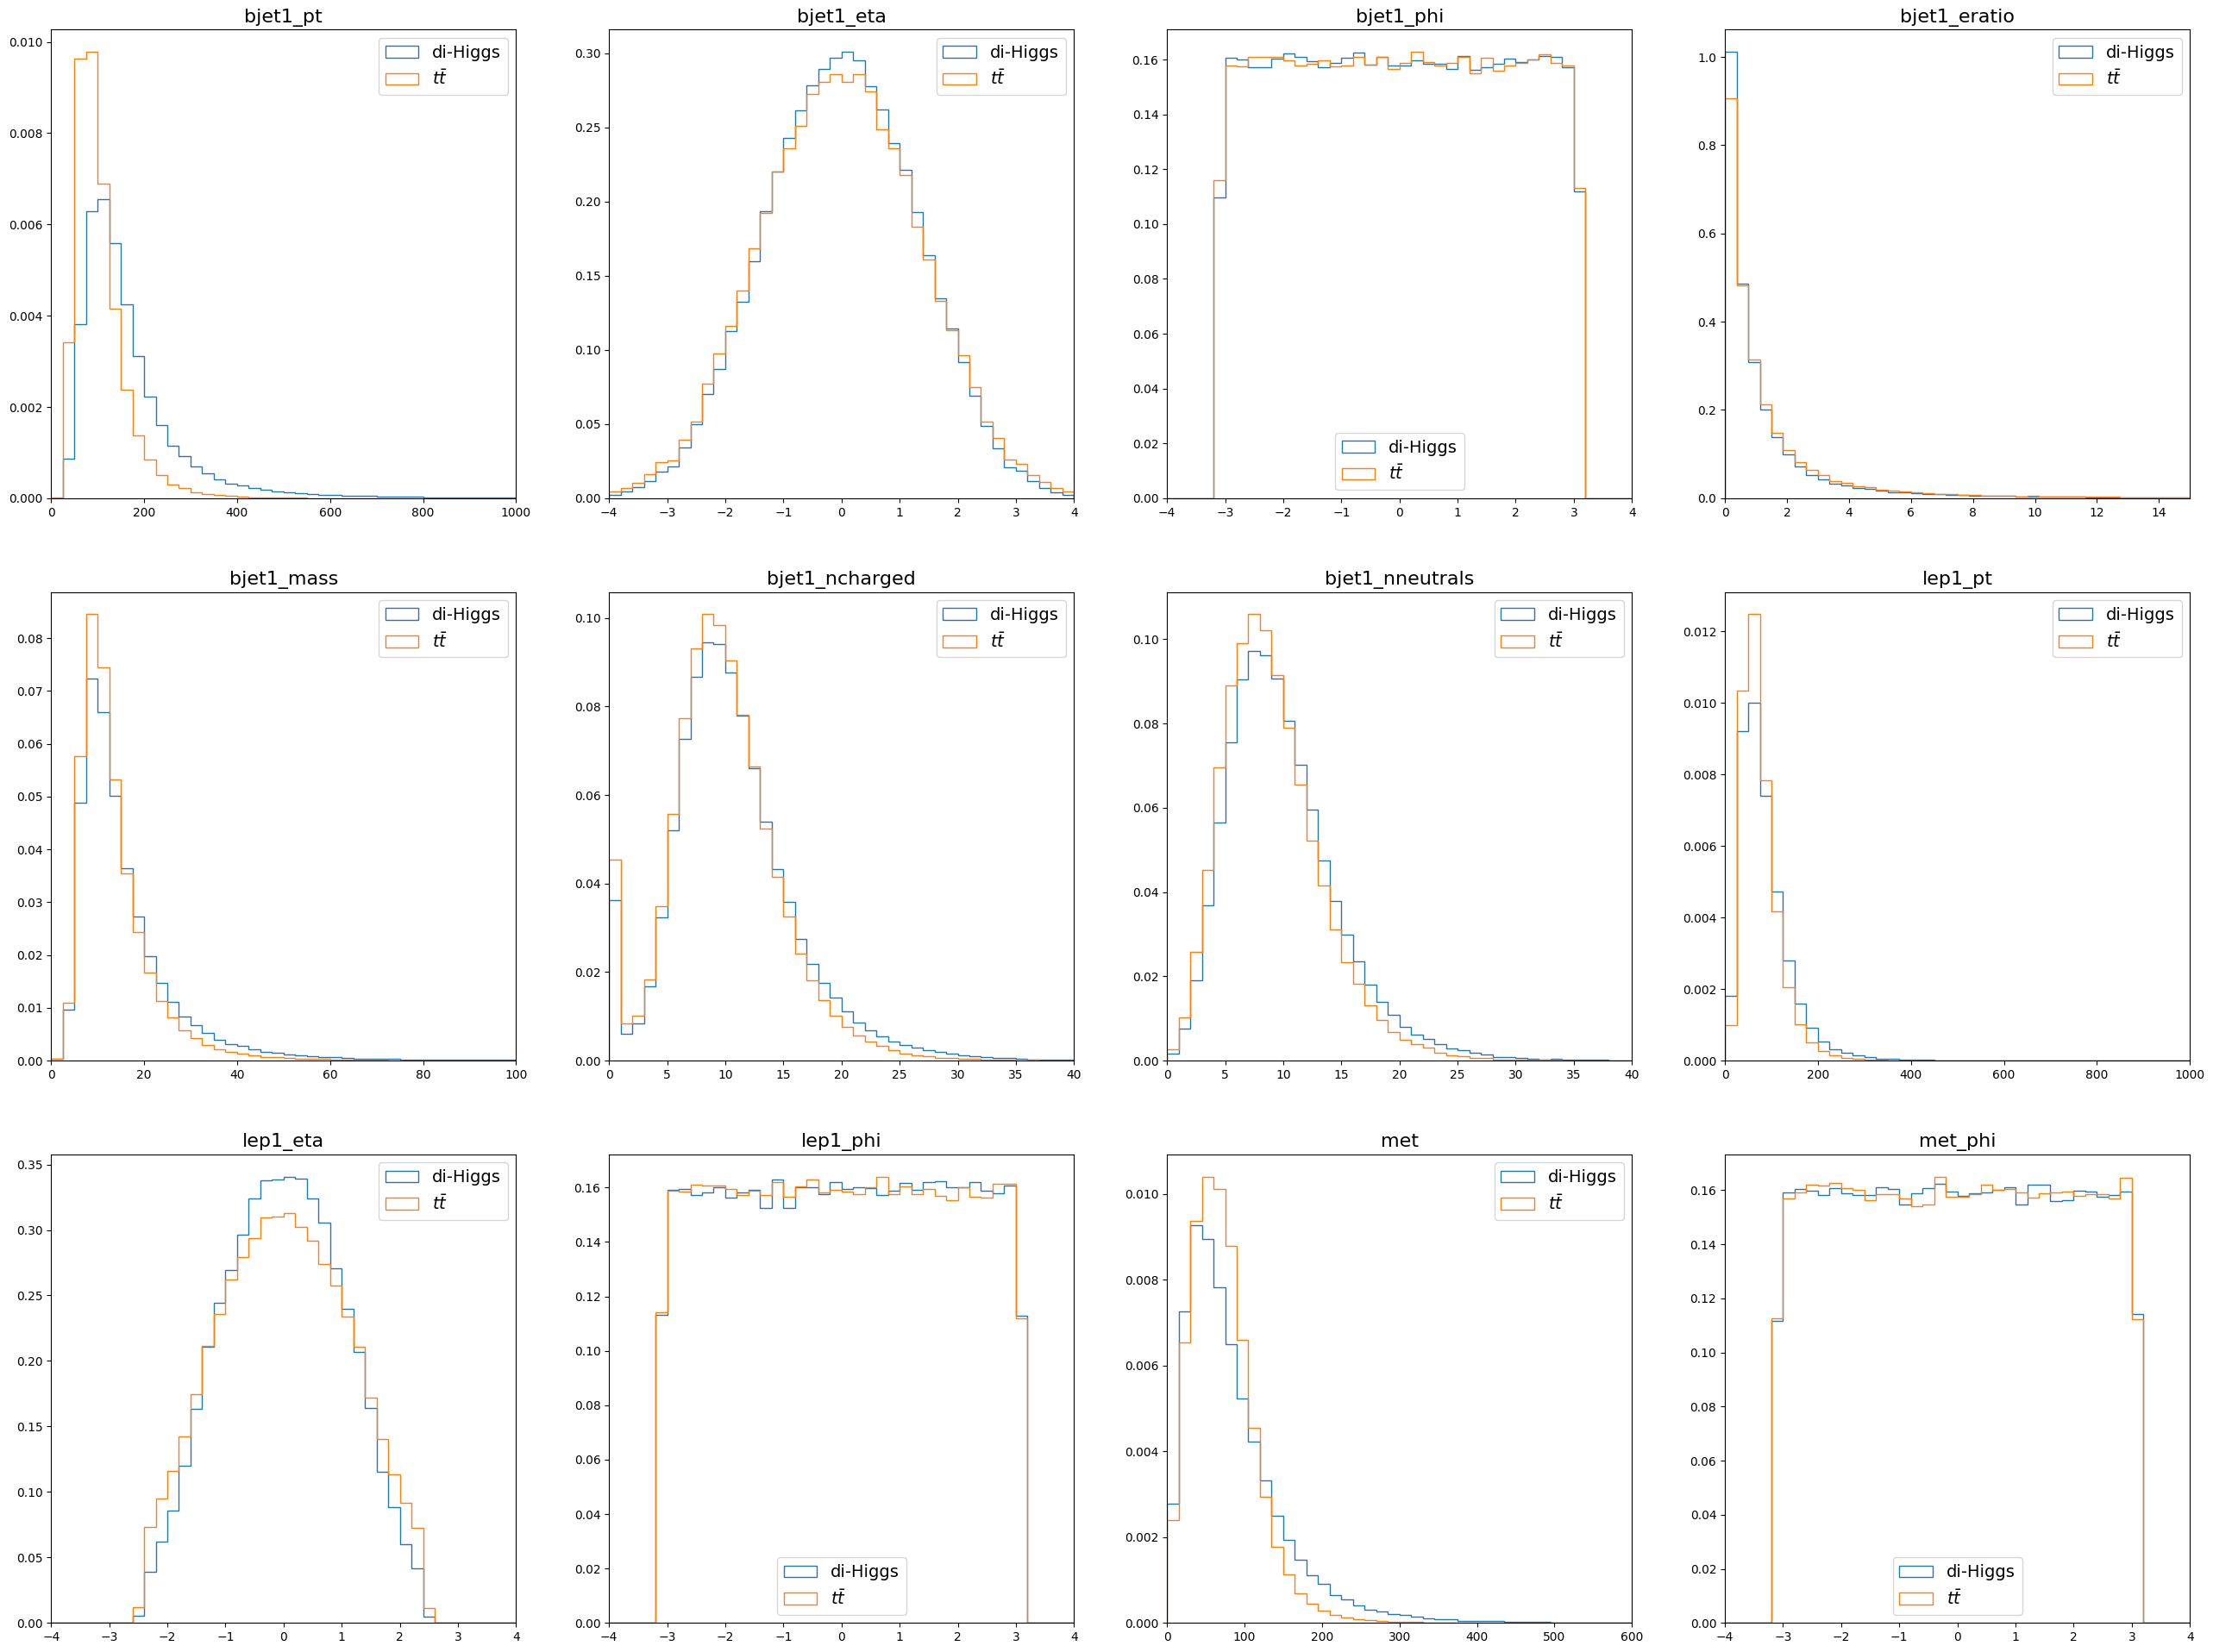

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Define a list of tuples for plotting: (variable name, number of bins, x-axis min, x-axis max)
plotinfo = [ # varname, nbin, xmin, xmax
    ('bjet1_pt', 40, 0, 1000),         # Leading b-jet transverse momentum
    ('bjet1_eta', 40, -4, 4),          # Leading b-jet pseudorapidity
    ('bjet1_phi', 40, -4, 4),          # Leading b-jet azimuthal angle
    ('bjet1_eratio', 40, 0, 15),       # Leading b-jet ECAL-to-HCAL energy deposit ratio
    ('bjet1_mass', 40, 0, 100),        # Leading b-jet mass
    ('bjet1_ncharged', 40, 0, 40),     # Number of charged particles in leading b-jet
    ('bjet1_nneutrals', 40, 0, 40),    # Number of neutral particles in leading b-jet
    ('lep1_pt', 40, 0, 1000),          # Leading lepton transverse momentum
    ('lep1_eta', 40, -4, 4),           # Leading lepton pseudorapidity
    ('lep1_phi', 40, -4, 4),           # Leading lepton azimuthal angle
    ('met', 40, 0, 600),               # Missing transverse energy
    ('met_phi', 40, -4, 4),            # Missing transverse energy azimuthal angle
]

plt.figure(figsize=(32, 24))  # Set the overall figure size for all subplots

for i, (varname, nbin, xmin, xmax) in enumerate(plotinfo):
    plt.subplot(3, 4, i+1)  # Arrange subplots in a 3x4 grid
    bins = np.linspace(xmin, xmax, nbin+1)  # Define bin edges for the histogram

    # Plot signal and background distributions for the current variable
    plt.hist(dihiggs[varname], histtype="step", bins=bins, label="di-Higgs", density=True)
    plt.hist(ttbar[varname], histtype="step", bins=bins, label="$t\\bar{t}$", density=True)

    plt.legend(fontsize=14)  # Add legend with specified font size
    plt.xlim(xmin, xmax)     # Set x-axis limits
    plt.title(varname, fontsize=16)  # Set subplot title as variable name

Notice that, when looking at individual physics objects, it is hard to distinguish between the two processes.

But what if we consider the correlations between multiple physics objects? Will the separation improve?

Text(0.5, 1.0, '$\\Delta\\eta_{l_1,l_2}$')

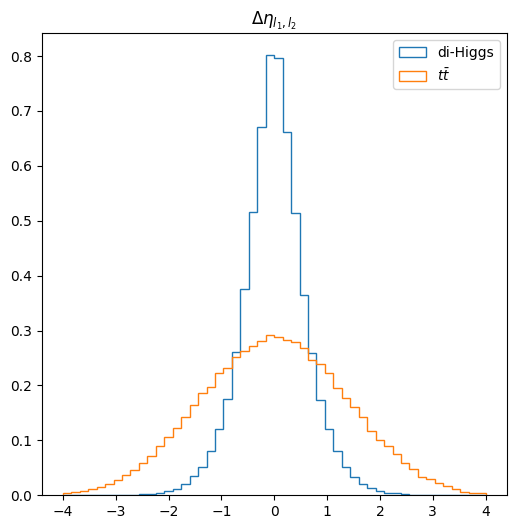

In [5]:
# Making a distribution plot for "lep1_eta - lep2_eta"

plt.figure(figsize=(6, 6))
plt.hist(dihiggs['lep1_eta'] - dihiggs['lep2_eta'], histtype="step", bins=np.linspace(-4,4,50+1), label="di-Higgs", density=True)
plt.hist(ttbar['lep1_eta'] - ttbar['lep2_eta'], histtype="step", bins=np.linspace(-4,4,50+1), label=r"$t\bar{t}$", density=True)
plt.legend()
plt.title(r"$\Delta\eta_{l_1,l_2}$")

We can see that in the di-Higgs process, both W bosons come from the Higgs, so the leptons from their decays tend to be closer together. In contrast, in the ttbar process, the two W bosons come from two separate top quarks, so the leptons are more likely to be back-to-back.

This shows that if we use machine learning methods and include multiple kinematic variables in our analysis, we can take advantage of the correlations between these variables to more efficiently separate signal from background.


### Prepare the dataset

In [6]:
# Define the features and labels
X = df_raw[['bjet1_pt', 'bjet1_eta', 'bjet1_phi',
       'bjet1_eratio', 'bjet1_mass', 'bjet1_ncharged', 'bjet1_nneutrals',
       'bjet2_pt', 'bjet2_eta', 'bjet2_phi', 'bjet2_eratio', 'bjet2_mass',
       'bjet2_ncharged', 'bjet2_nneutrals', 'lep1_pt', 'lep1_phi', 'lep1_eta',
       'lep1_charge', 'lep1_type', 'lep2_pt', 'lep2_phi', 'lep2_eta',
       'lep2_charge', 'lep2_type', 'met', 'met_phi']]
y = df_raw[['is_sig', 'is_bkg']] 

Let's first split the dataset into three parts: training, validation, and testing samples (the validation set won't be used in the following training task yet). We use the function provided by Sklearn to divide the data into these three sets with a ratio of 80/10/10%:

In [7]:
from sklearn.model_selection import train_test_split

# First, split the original dataset into a training set (80%) and a temporary validation/test set (20%)
X_train, X_valtest, y_train, y_valtest = train_test_split(X, y, test_size=0.2)

# The final split ratio is: training/validation/test = 80/10/10
X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size=0.5)

## A simple test with a linear model

To show the power of machine learning algorithms, let's first try to solve this problem using a basic linear model.

Logistic Regression is a classic machine learning method for binary classification (0 or 1), and it was proposed as early as the 19th century. In simple terms, for each data point and its label $(\mathbf{x}, y)$, logistic regression applies a linear transformation to $\mathbf{x}$, and then uses the sigmoid function to estimate the probability that $y$ is 1:

$$P(Y=1|\mathbf{x}) = \frac{1}{1 + e^{\mathbf{w}\cdot\mathbf{x} + \mathbf{b}}}$$


In [8]:
from sklearn.linear_model import LogisticRegression

# Initialize a logistic regression classifier with no regularization (penalty=None)
# set random seed for reproducibility, and increase max iterations for convergence
clf = LogisticRegression(random_state=0, penalty=None, max_iter=2000).fit(X_train, y_train['is_sig'])

# Evaluate the classifier on the validation set and return the accuracy score
clf.score(X_val, y_val['is_sig'])

0.6977666666666666

In [9]:
# Now we evaluate the performance of the linear model on the test set
test_score = clf.predict_proba(X_test)
test_score_sig = test_score[y_test['is_sig']][:, 1]
test_score_bkg = test_score[y_test['is_bkg']][:, 1]

Let's plot the distribution of model scores on the test set.

> We can see that logistic regression provides some separation between signal and background, but the separation is not very strong.

(0.0, 1.0)

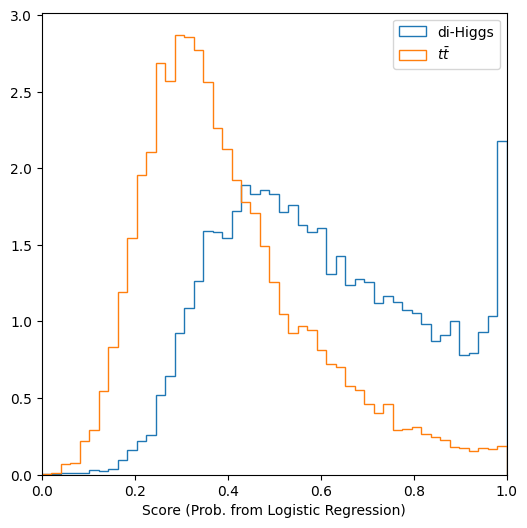

In [10]:
plt.figure(figsize=(6, 6))
hist_sig = plt.hist(test_score_sig, label=r"di-Higgs", histtype="step", bins=np.linspace(0,1), density=True)
hist_bkg = plt.hist(test_score_bkg, label=r"$t\bar{t}$", histtype="step", bins=np.linspace(0,1), density=True)
plt.xlabel("Score (Prob. from Logistic Regression)")
plt.legend()
plt.xlim(0,1)

## ROC curve and AUC

How do we measure how well the model separates signal from background?
Let's do a thought experiment: if we apply any monotonic transformation to the score, for example $x \mapsto x^2$, the ability to separate signal and background does not change. For a previous cut at $x > x_0$, we can simply cut at $x_0^2$ in the new score to keep the same number of signal and background events. So, we need a metric that does not depend on the exact shape of the score distribution.

Generally, for a classification problem, we usually set a threshold on the model's score to decide if an event is classified as signal or background. Based on this threshold, we can define two important quantities: the **True Positive Rate (TPR)**, which is the fraction of signal events correctly identified as signal, and the **False Positive Rate (FPR)**, which is the fraction of background events incorrectly identified as signal.

Choosing the threshold is always a trade-off: if the threshold is too low, the **FPR** increases; if the threshold is too high, the **TPR** decreases.

To evaluate a classification model, we often use the **Receiver Operating Characteristic (ROC) curve**. This curve is constructed as follows:
 1. For each threshold $x_0$, calculate the corresponding **TPR** and **FPR**.
 2. By varying $x_0$ from 0 to 1, we can plot the pairs (**TPR**, **FPR**) to form the ROC curve.

See the animation below to understand how the ROC curve is created.

<img src="figures/roc-animation.gif" alt="Drawing" width=900/>

Sklearn provides built-in functions that make it easy to plot the **ROC** curve.

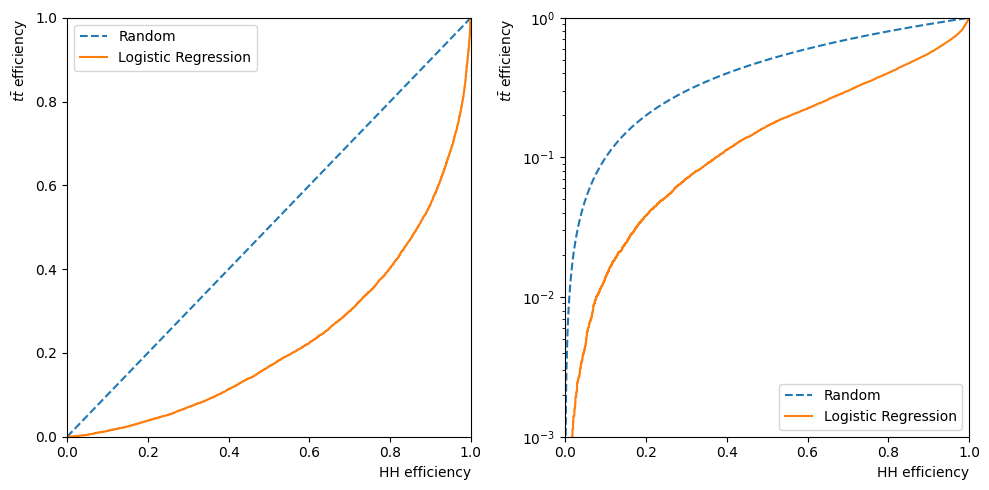

In [12]:
import sklearn.metrics as m

# Compute the ROC curve for the classifier
# fpr_clf: False Positive Rate (background efficiency)
# tpr_clf: True Positive Rate (signal efficiency)
# _thres: thresholds used to compute the ROC
fpr_clf, tpr_clf, _thres = m.roc_curve(y_test['is_sig'], test_score[:,1])

# Create a figure with two subplots: one linear, one log scale
f = plt.figure(figsize=(10, 5), tight_layout=True)
ax1 = f.add_subplot(1, 2, 1)
ax2 = f.add_subplot(1, 2, 2)

# Loop over axes to plot ROC curve in both linear and log y-scale
for ax, ax_type in zip([ax1, ax2], ['linear', 'log']):
    ax.cla()
    # Plot the "random" classifier line (diagonal)
    ax.plot(np.linspace(0, 1, 1000), np.linspace(0, 1, 1000), '--', label='Random')
    # Plot the ROC curve for the logistic regression model
    ax.plot(tpr_clf, fpr_clf, label='Logistic Regression')
    if ax_type == 'linear':
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    elif ax_type == 'log':
        ax.set_xlim(0, 1)
        ax.set_ylim(1e-3, 1)
        ax.set_yscale('log')
    # Set axis labels: signal efficiency (HH) vs. background efficiency (ttbar)
    ax.set_xlabel('HH efficiency', ha='right', x=1.0)
    ax.set_ylabel(r'$t\bar{t}$ efficiency', ha='right', y=1.0)
    ax.legend()

The "random" line shows what happens if we assign each sample a random probability between 0 and 1. In this case, no matter what threshold we choose, the expected TPR (True Positive Rate) and FPR (False Positive Rate) will be equal. For example, if the threshold is 0.4, both TPR and FPR will be (1-0.4)=0.6, since the scores are random.

Looking at the ROC curve, we can see that logistic regression does help improve the signal efficiency. For the same signal efficiency (TPR), logistic regression achieves a lower background efficiency (FPR), meaning it makes fewer mistakes than random guessing (the curve is below the random line).

For each ROC curve, we can use the **AUC (Area Under the Curve)** to directly measure the classifier's performance. AUC is defined as the area under the ROC curve, where the x-axis is FPR and the y-axis is TPR, as shown in the figure below.

> In high energy physics, we often plot TPR on the x-axis, so you can think of it as the area under or to the left of the ROC curve. It's also common in HEP to use a logarithmic scale for FPR (as shown on the right), because we usually care about very low FPR values (like 1e-3), and the log scale makes this region clearer.

<img src="figures/roc-curve-v2.png" alt="Drawing" width=500/>

## Training a BDT model

To better separate signal from background, relying only on linear relationships between kinematic variables is not enough. We need to take a further step!

Here, we learn to use tree-based models. Gradient Boosting Decision Trees (GBDT) and XGBoost are widely used in high energy physics. They have played a crucial role in the discovery of the Higgs boson in 2010s.

In the past (since 2007 and in 2010s), people often used the TMVA package in ROOT, which included many BDT algorithms and even some neural network methods. In the last decade, as artificial intelligence and data science have become more popular, Python has become the main language for data science, and high energy physics has also started using Python packages for BDT training. XGBoost was introduced in 2014 and quickly became popular in the machine learning community because of its efficiency, scalability, and strong performance. It is now a standard tool in HEP analyses.

Next, we will use XGBoost as an example.

In [13]:
# Import the XGBoost classifier
from xgboost import XGBClassifier

# Initialize the XGBoost classifier with logloss as the evaluation metric
# and fit it to the training data (X_train, y_train['is_sig'])
xgbc = XGBClassifier(eval_metric="logloss").fit(X_train, y_train['is_sig'])

In [14]:
# Get the predicted probabilities for the test set
test_score_xgb = xgbc.predict_proba(X_test)

# Select the predicted probability for the signal class (class 1) for signal and background events
test_score_xgb_sig = test_score_xgb[y_test['is_sig']][:, 1]
test_score_xgb_bkg = test_score_xgb[y_test['is_bkg']][:, 1]

(0.0, 1.0)

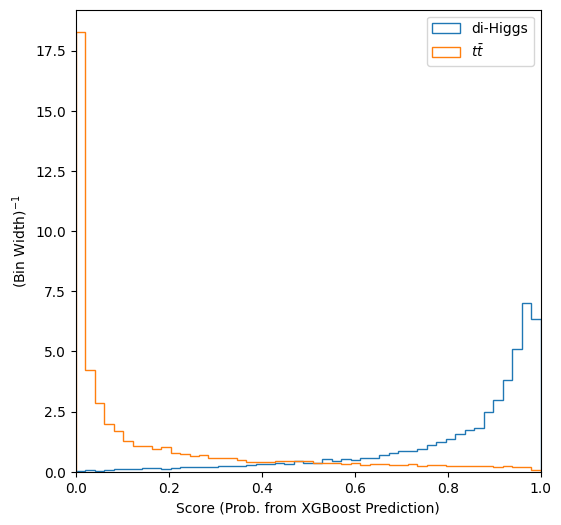

In [15]:
# Plot the distribution of XGBoost scores for signal and background events
plt.figure(figsize=(6, 6))
hist_sig = plt.hist(test_score_xgb_sig, label=r"di-Higgs", histtype="step", bins=np.linspace(0,1), density=True)
hist_bkg = plt.hist(test_score_xgb_bkg, label=r"$t\bar{t}$", histtype="step", bins=np.linspace(0,1), density=True)
plt.xlabel("Score (Prob. from XGBoost Prediction)")
plt.ylabel("(Bin Width)$^{-1}$")
plt.legend()
plt.xlim(0,1)

As we can see, even with the default settings, XGBoost already gives impressive classification results.

Here are some commonly used XGBoost parameters you can tune:

 1. `learning_rate`: XGBoost is a boosting algorithm. Although its optimization is not exactly the same as standard gradient-based methods, it still uses a similar idea. This parameter controls the "step size" at each iteration.
 2. Since XGBoost is a tree-based model, parameters related to the tree structure are important, such as the maximum tree depth (`max_depth`) or the number of leaf nodes (`max_leaf_nodes`). Generally, smaller values help prevent overfitting, but if they are too small, the model may not be powerful enough.
 3. There are also other parameters related to the loss function and training process. You can find more details in the [official documentation](https://xgboost.readthedocs.io/en/stable/).

Next, let's plot the ROC curve:

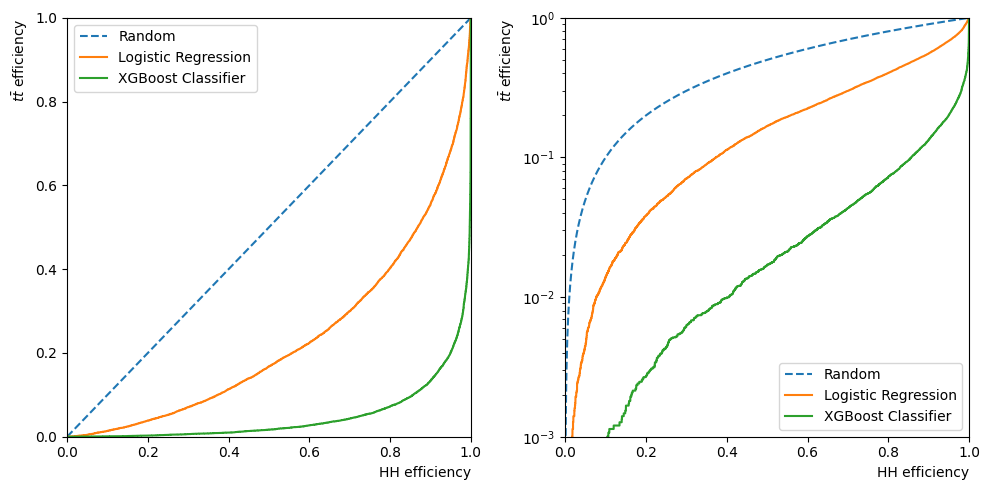

In [16]:
import sklearn.metrics as m
fpr_xgb, tpr_xgb, _thres = m.roc_curve(y_test['is_sig'], test_score_xgb[:,1])

f = plt.figure(figsize=(10, 5), tight_layout=True)
ax1 = f.add_subplot(1, 2, 1)
ax2 = f.add_subplot(1, 2, 2)

# Loop over axes to plot ROC curve in both linear and log y-scale
for ax, ax_type in zip([ax1, ax2], ['linear', 'log']):
    ax.cla()
    ax.plot(np.linspace(0, 1, 1000), np.linspace(0, 1, 1000), '--', label='Random')
    ax.plot(tpr_clf, fpr_clf, label='Logistic Regression')
    ax.plot(tpr_xgb, fpr_xgb, label='XGBoost Classifier')
    if ax_type == 'linear':
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    elif ax_type == 'log':
        ax.set_xlim(0, 1)
        ax.set_ylim(1e-3, 1)
        ax.set_yscale('log')
    ax.set_xlabel('HH efficiency', ha='right', x=1.0)
    ax.set_ylabel(r'$t\bar{t}$ efficiency', ha='right', y=1.0)
    ax.legend()


> XGBoost (like other BDT models) shows its strong performance!

Finally, let's try to understand what XGBoost has learned. We want to check which input features are most important for the classification.

XGBoost provides a function called `plot_importance` that can show how important each feature is for the model.

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

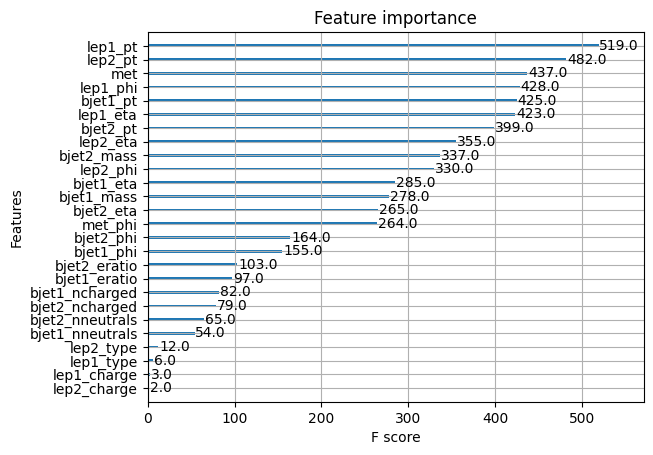

In [17]:
from xgboost import plot_importance
plot_importance(xgbc)

> XGBoost supports several ways to measure feature importance, such as weight, gain, cover, total_cover, and total_gain. These metrics reflect feature importance from different perspectives.

> The F-score is a common metric used in decision tree models to measure how important a feature (in our case, a kinematic variable) is. It counts how many times a feature is used to split the data during the classification process.

Finally, let's save the ROC curve data for later use.

In [18]:
os.makedirs('data', exist_ok=True)
np.savetxt("data/roc_lr.dat", [tpr_clf, fpr_clf])
np.savetxt("data/roc_xgb.dat", [tpr_xgb, fpr_xgb])

## Training a DNN model

Now let's switch to using a deep neural network (DNN) model!

Neural networks have been around since the 1980s, when they were called artificial neural networks (ANNs). However, it wasn't until around 2012, when hardware became powerful enough, that deep neural networks became popular again. Since then, people have been able to train large and deep networks, and deep learning has achieved great success, especially in image classification competitions like ImageNet. This marked the beginning of the deep learning era.

To get an intuitive understanding of how neural networks work, we highly recommend watching the 3Blue1Brown video series after class. The visualizations are excellent.
> https://www.bilibili.com/video/BV1bx411M7Zx/ (There are three parts)

Today, we will mainly introduce neural networks through slides.

### Introduction to PyTorch

We will use PyTorch to build our neural networks. PyTorch is an open-source machine learning framework that allows users to freely design and efficiently train their own neural networks. PyTorch is not the only deep learning framework—others include TensorFlow, JAX, and Caffe.

Today, PyTorch has a very mature ecosystem and a large developer community (it was originally developed by Facebook). It is very flexible and widely used in research. Many recent research papers release their code in PyTorch.
The figure below shows the share of PyTorch and other frameworks in research papers. You can see that PyTorch now dominates more than half of the field.

<img src="figures/percentage_repo_2023.png" alt="image" width=700/>

In general, building and training networks with PyTorch can take a bit more work—especially for beginners, who often use easier tools like Keras. But as deep learning has grown quickly in recent years, PyTorch has become very popular among researchers. That’s why we use PyTorch in this tutorial, so we can keep up with the latest trends in deep learning. In the next section (for self-reading), we will also look at more advanced models like Transformers, which are built by PyTorch as well.

In short, building a network is like building a castle out of LEGO blocks—PyTorch provides the basic building blocks, while some high-level packages only offer a few pre-built castles to choose from.

In our tutorial, we will also use pytorch-lightning on top of PyTorch. This package wraps some common PyTorch settings, making our code shorter and easier to read.

If you want to systematically learn PyTorch, you can check out the following resources:
 - PyTorch official 60-minute tutorial: https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html
 - UvA teaching materials: https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial2/Introduction_to_PyTorch.html

Next, let's introduce the basic elements needed to train with PyTorch:
 - Model: building a PyTorch model (`nn.Module`) is like assembling LEGO blocks. You use basic nn.BlaBla blocks to build the model you want. In the `__init__` method, you set up the building blocks, and in the `forward` method, you define how data flows through the network. For a simple neural network, you can define several nn.Linear layers, and in the forward method, connect them in the order: Linear layer -> ReLU activation -> Linear layer -> ReLU activation -> Linear layer.
 - Dataset: our dataset is the same as in the previous example, but we need to load it using PyTorch's dataset format. In this class, we define the total number of samples (`__len__`) and a `__getitem__` function to get the item at a specific index.

For example, below is a simple `nn.Module`! Try to understand what it does.

In [19]:
import torch

# Define a simple neural network model using PyTorch
class TinyModel(torch.nn.Module):

    def __init__(self):
        super(TinyModel, self).__init__()
        self.linear1 = torch.nn.Linear(100, 200)  # First linear layer: input size 100, output size 200
        self.activation = torch.nn.ReLU()         # ReLU activation function
        self.linear2 = torch.nn.Linear(200, 10)   # Second linear layer: input size 200, output size 10
        self.softmax = torch.nn.Softmax()         # Softmax activation for output layer (for multi-class classification)

    def forward(self, x):
        x = self.linear1(x)                       # Pass input through first linear layer
        x = self.activation(x)                    # Apply ReLU activation
        x = self.linear2(x)                       # Pass through second linear layer
        x = self.softmax(x)                       # Apply softmax to get class probabilities
        return x

# Instantiate the model
tinymodel = TinyModel()

# Print the full model architecture
print('The model:')
print(tinymodel)

# Print only the second linear layer
print('\n\nJust one layer:')
print(tinymodel.linear2)

# Print all parameters of the model
print('\n\nModel params:')
for param in tinymodel.parameters():
    print(param)

# Print parameters of the second linear layer only
print('\n\nLayer params:')
for param in tinymodel.linear2.parameters():
    print(param)

The model:
TinyModel(
  (linear1): Linear(in_features=100, out_features=200, bias=True)
  (activation): ReLU()
  (linear2): Linear(in_features=200, out_features=10, bias=True)
  (softmax): Softmax(dim=None)
)


Just one layer:
Linear(in_features=200, out_features=10, bias=True)


Model params:
Parameter containing:
tensor([[-0.0850,  0.0979,  0.0062,  ..., -0.0719,  0.0165,  0.0696],
        [-0.0830,  0.0200,  0.0087,  ...,  0.0376,  0.0687,  0.0785],
        [-0.0525,  0.0012,  0.0428,  ...,  0.0307,  0.0361,  0.0716],
        ...,
        [ 0.0446, -0.0166,  0.0515,  ..., -0.0272,  0.0671,  0.0510],
        [-0.0876,  0.0541,  0.0725,  ..., -0.0970, -0.0276, -0.0959],
        [ 0.0901,  0.0421,  0.0137,  ..., -0.0204, -0.0525, -0.0116]],
       requires_grad=True)
Parameter containing:
tensor([-0.0968, -0.0721,  0.0807,  0.0353, -0.0960, -0.0766, -0.0392,  0.0117,
        -0.0535,  0.0442,  0.0461, -0.0728, -0.0100, -0.0962,  0.0215, -0.0470,
         0.0139, -0.0340,  0.0749,  0.00

### Preparing data for DNN training

Training a neural network (DNN) usually takes more care than training a BDT. Preparing the dataset properly is very important.

In general, neural networks learn better if the input features are on similar scales. If the input features have very different ranges (for example, some are always between 0 and 1, while others like jet pT can be in the thousands), the weights in the first layer can vary a lot, making optimization harder.

To help the network train well, we standardize each feature: subtract the mean and divide by the standard deviation.

> Note: For variables with long tails, like jet $p_\mathrm{T}$, besides standardization, it is common to apply a log transformation, such as $\log(|x|)$ or $\log(|x|+1)$, to make the distribution more Gaussian-like. This can also help improve network performance.


In [20]:
# Initialize the StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

input_columns = ['bjet1_pt', 'bjet1_eta', 'bjet1_phi',
       'bjet1_eratio', 'bjet1_mass', 'bjet1_ncharged', 'bjet1_nneutrals',
       'bjet2_pt', 'bjet2_eta', 'bjet2_phi', 'bjet2_eratio', 'bjet2_mass',
       'bjet2_ncharged', 'bjet2_nneutrals', 'lep1_pt', 'lep1_phi', 'lep1_eta',
       'lep1_charge', 'lep1_type', 'lep2_pt', 'lep2_phi', 'lep2_eta',
       'lep2_charge', 'lep2_type', 'met', 'met_phi']

# Fit and transform the DataFrame
df_trans = pd.DataFrame(scaler.fit_transform(df_raw[input_columns]), columns=[c + '_trans' for c in input_columns], index=df_raw.index)
df = pd.concat([df_trans, df_raw], axis=1)
df

,bjet1_pt_trans,bjet1_eta_trans,bjet1_phi_trans,bjet1_eratio_trans,bjet1_mass_trans,bjet1_ncharged_trans,bjet1_nneutrals_trans,bjet2_pt_trans,bjet2_eta_trans,bjet2_phi_trans,...,lep1_charge,lep1_type,lep2_pt,lep2_phi,lep2_eta,lep2_charge,lep2_type,met,met_phi,label
0,0.566009,-0.216940,-0.538931,-0.142020,0.165628,0.430743,-0.663944,-0.127634,-1.025722,-0.312706,...,1,0,17.508558,1.165262,-0.711694,-1,0,233.613846,2.300718,1
1,-0.692736,-0.913453,1.316571,-0.140433,0.032240,0.037705,0.213418,-0.177743,-0.332485,-1.051495,...,1,1,50.567219,-1.089323,0.409210,-1,1,102.682526,-0.004101,1
2,0.170040,0.341568,-0.809302,-0.134763,-0.249359,0.430743,-0.225263,-0.270861,0.921192,-1.382473,...,1,1,43.384056,0.584961,0.624317,-1,0,57.796436,0.935978,1
3,-0.294402,0.095947,-0.646589,-0.144293,-0.818660,-0.748372,-1.102625,-0.959167,1.114436,-0.866333,...,1,1,26.664654,2.175398,0.556468,-1,1,65.674774,1.417736,1
4,-0.400051,1.630488,-1.619534,-0.144293,-0.410070,0.037705,1.090781,-0.542826,1.505292,-0.814446,...,-1,1,29.825296,0.306789,0.310836,1,0,94.994255,-3.043913,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,0.346695,-0.108884,1.646368,-0.142651,1.135805,0.430743,-0.225263,0.927557,0.108459,-1.172372,...,-1,1,92.388741,-0.697610,0.483596,1,1,131.839859,-0.000835,0
149996,-0.910265,0.757730,-0.888382,-0.144293,-0.499778,0.037705,-0.225263,-0.592341,2.543271,0.839254,...,-1,0,62.515564,0.693190,0.890577,1,0,75.465065,1.878048,0
149997,-0.738931,0.289773,0.273378,-0.142988,-0.553964,0.037705,-0.225263,-0.640201,-0.014030,-0.854679,...,1,0,34.591877,2.737549,-0.180914,-1,1,59.409447,0.176429,0
149998,-0.482243,-0.421251,-0.350626,-0.139206,-0.120629,0.234224,0.652100,-0.176126,-0.564892,0.026914,...,-1,1,20.882822,-3.140386,-1.086141,1,0,44.600636,-1.177096,0


### Start training!

We will build a simple neural network to perform a basic binary classification task.

<img src="figures/NN_for_event_classification.jpg" alt="image" width=900/>

Next, let's define our PyTorch model and set up the PyTorch Lightning Trainer:

In [21]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import lightning as L
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch import nn
import torchmetrics

# Define the PyTorch Lightning model for a simple multilayer perceptron (MLP)
class SimpleMLP(L.LightningModule):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleMLP, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)   # First fully connected layer
        self.layer2 = nn.Linear(hidden_size, hidden_size)  # Second fully connected layer
        self.layer3 = nn.Linear(hidden_size, output_size)  # Output layer

        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=output_size)  # Accuracy metrics for training
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=output_size)    # Accuracy metrics for validation

    def forward(self, x):
        # Forward pass: input -> relu -> hidden -> relu -> output
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.layer3(x)
        return x

    def training_step(self, batch, batch_idx):
        # Defines the operations for each training batch
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.train_acc(logits, y)
        # Log training loss and accuracy
        self.log('train_loss', loss)
        self.log('train_acc', self.train_acc, on_step=False, on_epoch=True)
        # Log current learning rate
        self.log('lr', self.trainer.optimizers[0].param_groups[0]['lr'])
        return loss

    def validation_step(self, batch, batch_idx):
        # Defines the operations for each validation batch
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.val_acc(logits, y)
        # Log validation loss and accuracy
        self.log('val_loss', loss)
        self.log('val_acc', self.val_acc, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        # Set up optimizer and learning rate scheduler
        optimizer = torch.optim.Adam(self.parameters(), lr=0.001)
        
        # Learning rate schedule: constant for 70% of epochs, then exponential decay to 1% of initial value
        def lr_lambda(epoch):
            if epoch < 0.7 * self.trainer.max_epochs:
                return 1.0
            else:
                decay_factor = (epoch - 0.7 * self.trainer.max_epochs) / (0.3 * self.trainer.max_epochs)
                return 0.01 ** decay_factor

        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
        return [optimizer], [scheduler]


# Define a custom PyTorch Dataset to wrap a pandas DataFrame
# See: https://pytorch.org/tutorials/beginner/basics/data_tutorial.html
class DataFrameDataset(Dataset):
    def __init__(self, dataframe, input_columns, target_column):
        # Store the dataframe and extract input features and targets
        self.dataframe = dataframe
        self.inputs = dataframe[input_columns].values
        self.targets = dataframe[target_column].values

    def __len__(self):
        # Return the number of samples in the dataset
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Retrieve the input features and label for a given index
        x = torch.tensor(self.inputs[idx], dtype=torch.float32)  # N-dimensional input features
        y = torch.tensor(self.targets[idx], dtype=torch.long)    # 1-dimensional label
        return x, y

After defining the PyTorch Model and Dataset classes, we need to initialize them.

Everything starts from the pandas dataframe, which holds our data and is used as input for the PyTorch Dataset. With the Dataset, we use PyTorch's built-in DataLoader to sample data. Here, we set the `batch_size`, which means how many samples are in each batch during training. The DataLoader will group the data into multi-dimensional tensors, where the first dimension is the `batch_size`, so the model processes the data batch by batch.

In [22]:
input_columns = ['bjet1_pt', 'bjet1_eta', 'bjet1_phi',
       'bjet1_eratio', 'bjet1_mass', 'bjet1_ncharged', 'bjet1_nneutrals',
       'bjet2_pt', 'bjet2_eta', 'bjet2_phi', 'bjet2_eratio', 'bjet2_mass',
       'bjet2_ncharged', 'bjet2_nneutrals', 'lep1_pt', 'lep1_phi', 'lep1_eta',
       'lep1_charge', 'lep1_type', 'lep2_pt', 'lep2_phi', 'lep2_eta',
       'lep2_charge', 'lep2_type', 'met', 'met_phi']
target_column = 'label'

# Split the data into training/validation/testing datasets following 80/10/10%
train_df, test_df = train_test_split(df, test_size=0.2)
val_df, test_df = train_test_split(test_df, test_size=0.5)

# Create datasets (remember to use the transformed features!)
train_dataset = DataFrameDataset(train_df, [c + '_trans' for c in input_columns], target_column)
val_dataset = DataFrameDataset(val_df, [c + '_trans' for c in input_columns], target_column)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024)

# Create Model instance
model_mlp = SimpleMLP(input_size=26, hidden_size=64, output_size=2)

In [23]:
# Trainer with a logger (you may change the name here!)
trainer = L.Trainer(max_epochs=50, logger=L.pytorch.loggers.TensorBoardLogger('tb_logs', name='simple_mlp'))

# Fit the model
trainer.fit(model_mlp, train_loader, val_loader)

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICE

### Monitoring training with Tensorboard

Tensorboard is a very useful tool for monitoring training and checking metrics. If you have used Jupyter before, Tensorboard works in a similar way: you start a Tensorboard service and then open it in your browser at a specific port.

In a notebook, you can start Tensorboard with the following magic command:

In [ ]:
# Load the tensorboard extension
%load_ext tensorboard

In [ ]:
# Start the tensorboard service (monitoring the "tb_logs" directory)
#### If this doesn't work, just visit it in your browser http://localhost:6006 ####

%tensorboard --logdir tb_logs

You will see a panel like this.

Pay attention to the "scalars" tab on the left. Here, you can observe how the model's accuracy and loss on the training and validation sets change during training.

 - As the network trains and gets optimized, **the accuracy should increase and the loss should decrease.**
 - The curves for the training and validation sets should be very similar. If the training curve is much better than the validation curve, it means the model is overfitting. (You can try making the network wider by increasing the hidden layer size, adding more layers, or training with only 1/10 of the current dataset to see what happens.)

<img src="figures/tensorboard_output.png" alt="image" width=500/>

### Performance evaluation

Let's use the trained model to perform inference on the test dataset and obtain the output results!

In a standard neural network training workflow, the dataset is typically split into three parts: 
training dataset, validation dataset, and test dataset. Here, we use the test dataset to evaluate the model's performance.

In [24]:
# This is a dataset class for inference (predicting scores).
# It returns only the input features, without the label.
# Compare this with the DataFrameDataset used for training/validation, which also returns the label.
class DataFrameDatasetForInference(Dataset):
    def __init__(self, dataframe, input_columns):
        self.inputs = dataframe[input_columns].values

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        x = torch.tensor(self.inputs[idx], dtype=torch.float32)
        return x

test_dataset = DataFrameDatasetForInference(test_df, [c + '_trans' for c in input_columns])
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

# If your model is saved, load it
# model_mlp = SimpleMLP.load_from_checkpoint('path_to_checkpoint.ckpt')

# Use the trainer to predict
predictions_mlp = trainer.predict(model_mlp, dataloaders=test_loader)

# Flatten list of tensors
predictions_mlp = [p.numpy() for batch in predictions_mlp for p in batch]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/home/olympus/licq/utils/miniconda3/envs/weaver-uproot5/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=71` in the `DataLoader` to improve performance.


The predictions here are the two logits output by the last layer of the network. When we use `F.cross_entropy` to calculate the loss, it automatically applies softmax to the logits.
Therefore, our logits are not normalized yet, and we need to manually apply softmax to get probabilities.

> Please make sure you understand why this step is needed.

In [25]:
test_score = np.array([np.exp(p[1]) / (np.exp(p[0]) + np.exp(p[1])) for p in predictions_mlp])

Now we can plot the distribution of the scores. Compare the results with the previous section to see if the separation between signal and background has improved. Also, plot the ROC curve to compare all the models we have used so far.

(0.0, 1.0)

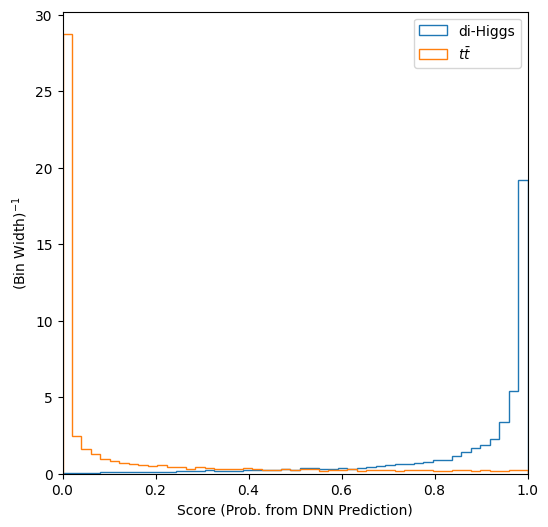

In [29]:
plt.figure(figsize=(6, 6))
hist_sig = plt.hist(test_score[test_df['is_sig']], label=r"di-Higgs", histtype="step", bins=np.linspace(0,1), density=True)
hist_bkg = plt.hist(test_score[test_df['is_bkg']], label=r"$t\bar{t}$", histtype="step", bins=np.linspace(0,1), density=True)
plt.xlabel("Score (Prob. from DNN Prediction)")
plt.ylabel("(Bin Width)$^{-1}$")
plt.legend()
plt.xlim(0,1)

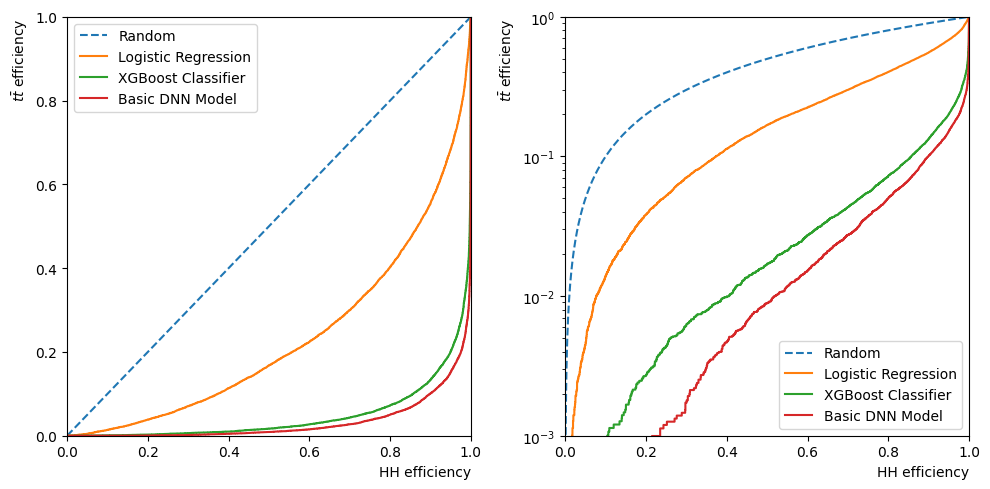

In [31]:
# Draw the ROC curve

import sklearn.metrics as m
fpr, tpr, _thres = m.roc_curve(test_df['is_sig'], test_score)

import matplotlib.pyplot as plt
import matplotlib as mpl
import mplhep as hep

# Create a figure with two subplots: one linear, one log scale
f = plt.figure(figsize=(10, 5), tight_layout=True)
ax1 = f.add_subplot(1, 2, 1)
ax2 = f.add_subplot(1, 2, 2)

# Loop over axes to plot ROC curve in both linear and log y-scale
for ax, ax_type in zip([ax1, ax2], ['linear', 'log']):

    ## the random guess line
    ax.plot(np.linspace(0, 1, 1000), np.linspace(0, 1, 1000), '--', label='Random')
    
    ## first include the ROC curves from the previous ML tasks
    tpr_clf, fpr_clf = np.loadtxt("data/roc_lr.dat")
    tpr_xgb, fpr_xgb = np.loadtxt("data/roc_xgb.dat")
    ax.plot(tpr_clf, fpr_clf, label='Logistic Regression')
    ax.plot(tpr_xgb, fpr_xgb, label='XGBoost Classifier')

    # then plot the ROC curve of the current DNN model
    ax.plot(tpr, fpr, label='Basic DNN Model')

    if ax_type == 'linear':
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    elif ax_type == 'log':
        ax.set_xlim(0, 1)
        ax.set_ylim(1e-3, 1)
        ax.set_yscale('log')
    ax.set_xlabel('HH efficiency', ha='right', x=1.0)
    ax.set_ylabel(r'$t\bar{t}$ efficiency', ha='right', y=1.0)
    ax.legend()

plt.show()

We can see that in this basic example, the DNN model performs better than the BDT.

This is also true in real experiments. For example, in high energy physics experiments like ATLAS and CMS, neural networks are now used more often than traditional BDT methods in physics analyses. Let's embrace these new approaches!

Finally, let's think about how we could train an even better DNNs for this task. (These are also part of our exercises.)
 - Which hyperparameters affect the performance of the neural network? Try changing different hyperparameters and see how the results change. (You may compare the training and evaluation curves in Tensorboard directly after the training.)
 - What kind of input features could improve the network's performance? Try changing the input variables (for example, adding new variables or skipping the normalization step) and see how it affects the network.

## Training a Transformer network (optional)

The following section is for self-reading. We may not cover this in detail during the tutorial, but as an extension of training DNNs, you can also try training a Transformer network using what you have learned about Transformers in class.

PyTorch already includes a built-in Transformer model. Although you could build a Transformer from basic building blocks, PyTorch provides a ready-to-use implementation that you can call directly.

> Reference link: https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html

<img src="figures/nn-MultiheadAttention.png" alt="Drawing" width=800/>



To inferface our input with the Transformer module, we need to perform a special **embedding step**.

### Token embedding

As you may remember, a Transformer takes tokens as input. Tokens are structured input units. Previously, our input was a list of separate features, so we need to group them properly. Here, we define each object as a token. Our objects are: **two b-jets, two leptons, and one missing transverse momentum (MET)**. Each token has its own set of features; for example, a b-jet has 7 features, and a lepton has 5.

The embedding step uses a simple DNN to convert the features of each token into the same size.

Below is our implementation of the embedding. Try to understand how the features of each token are transformed in this process.

In [34]:
class Embeddings(nn.Module):
    def __init__(self, config):
        super(Embeddings, self).__init__()
        self.token_embeddings = nn.ModuleDict()
        # Define embedding layers for each token type: bjet, lep, met
        # Each token type has its own input dimension: 7 for bjet, 5 for lep, 2 for met
        for token_name, in_dim in zip(['bjet', 'lep', 'met'], [7, 5, 2]):
            self.token_embeddings[token_name] = nn.Sequential(
                nn.Linear(in_dim, config.hidden_size),              # Project input features to hidden size
                nn.GELU(),                                          # Non-linear activation
                nn.Linear(config.hidden_size, config.hidden_size),  # Further transformation
            )

        self.layer_norm = nn.LayerNorm(config.hidden_size)  # Layer normalization for all tokens
        self.dropout = nn.Dropout(config.hidden_dropout_prob)  # Dropout for regularization
        # Add a trainable class token ([CLS]) for classification tasks
        self.class_token = nn.Parameter(torch.randn(1, config.hidden_size))

    def forward(self, input):
        # input shape: (batch_size, input_dim=26)
        embeddings = []
        # The first token is the [CLS] token, expanded to batch size
        embeddings.append(self.class_token.expand(input.size(0), -1))
        # Embed bjet1 features (first 7 elements)
        embeddings.append(self.token_embeddings['bjet'](input[:, :7]))
        # Embed bjet2 features (next 7 elements)
        embeddings.append(self.token_embeddings['bjet'](input[:, 7:14]))
        # Embed lep1 features (next 5 elements)
        embeddings.append(self.token_embeddings['lep'](input[:, 14:19]))
        # Embed lep2 features (next 5 elements)
        embeddings.append(self.token_embeddings['lep'](input[:, 19:24]))
        # Embed met features (last 2 elements)
        embeddings.append(self.token_embeddings['met'](input[:, 24:]))
        # Stack all token embeddings along the token dimension
        embeddings = torch.stack(embeddings, dim=1)
        # embeddings shape: (batch_size, num_tokens, hidden_size)
        embeddings = self.layer_norm(embeddings)  # Apply layer normalization
        embeddings = self.dropout(embeddings)     # Apply dropout
        return embeddings

### Transformer implementation

Next, we will start building the Transformer. Read the comments to understand what each line of code does. You can also refer to the slides to see which part of the Transformer each section corresponds to.

In [35]:
class BasicTransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_hidden_dim, attn_dropout=0.1, dropout=0.1):
        super(BasicTransformerBlock, self).__init__()
        # Multi-head self-attention layer
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=attn_dropout, batch_first=True)
        # First layer normalization (applied before attention)
        self.norm1 = nn.LayerNorm(embed_dim)
        # Feed-forward network: two linear layers with GELU activation in between
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_hidden_dim),
            nn.GELU(),
            nn.Linear(ff_hidden_dim, embed_dim)
        )
        # Second layer normalization (applied before feed-forward)
        self.norm2 = nn.LayerNorm(embed_dim)
        # Dropout layer for regularization
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Apply first layer normalization before self-attention
        x = self.norm1(x)
        # Self-attention: Q, K, V are all set to x (self-attention)
        attn_output, _ = self.attention(x, x, x)
        # Add & Norm: residual connection after attention + dropout
        x = x + self.dropout(attn_output)
        
        # Apply second layer normalization before feed-forward
        x = self.norm2(x)
        # Feed-forward network
        ff_output = self.ff(x)
        # Add & Norm: residual connection after feed-forward + dropout
        x = x + self.dropout(ff_output)

        return x


class BasicTransformerForClassification(nn.Module):
    def __init__(self, config):
        super().__init__()
        # Embedding layer to convert input features to token embeddings
        self.embeddings = Embeddings(config)
        # Stack of transformer blocks
        self.blocks = nn.ModuleList(
            [BasicTransformerBlock(
                config.hidden_size, 
                config.num_attention_heads, 
                config.intermediate_size, 
                attn_dropout=0., 
                dropout=config.hidden_dropout_prob
            ) for _ in range(config.num_hidden_layers)]
        )
        # Dropout before final classification
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        # Final linear layer for classification
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)

    def forward(self, x):
        # Pass input through embedding layer
        x = self.embeddings(x)
        # Pass through each transformer block
        for block in self.blocks:
            x = block(x)
        # Select the hidden state corresponding to the [CLS] token (first token)
        x = x[:, 0, :]
        # Apply dropout
        x = self.dropout(x)
        # Final classification layer
        x = self.classifier(x)
        return x

Next, we can start training using PyTorch Lightning!

In [36]:
from types import SimpleNamespace
config = SimpleNamespace(
    hidden_size = 16,  # Hidden size for embeddings and Transformer
    num_attention_heads = 4,  # Number of attention heads
    intermediate_size = 32,  # Feed forward intermediate size
    num_hidden_layers = 4,  # Number of Transformer layers
    hidden_dropout_prob = 0.,  # Dropout probability
    num_labels = 2  # Number of output classes
)

# Define the PyTorch Lightning model
class BasicTransformer(L.LightningModule):
    def __init__(self, config):
        super().__init__()
        self.mod = BasicTransformerForClassification(config)

        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=config.num_labels) # 帮助我们计算准确率的
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=config.num_labels)

    def forward(self, x):
        return self.mod(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.train_acc(logits, y)
        self.log('train_loss', loss)
        self.log('train_acc', self.train_acc, on_step=False, on_epoch=True)
        self.log('lr', self.trainer.optimizers[0].param_groups[0]['lr'])
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.val_acc(logits, y)
        self.log('val_loss', loss)
        self.log('val_acc', self.val_acc, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.001)
        
        def lr_lambda(epoch):
            if epoch < 0.7 * self.trainer.max_epochs:
                return 1.0
            else:
                decay_factor = (epoch - 0.7 * self.trainer.max_epochs) / (0.3 * self.trainer.max_epochs)
                return 0.01 ** decay_factor

        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda) # LR scheduler定义为从70% epoch开始，指数衰减到1%
        return [optimizer], [scheduler]

# Create Model instance
model_transformer = BasicTransformer(config)
print(model_transformer)


BasicTransformer(
  (mod): BasicTransformerForClassification(
    (embeddings): Embeddings(
      (token_embeddings): ModuleDict(
        (bjet): Sequential(
          (0): Linear(in_features=7, out_features=16, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=16, out_features=16, bias=True)
        )
        (lep): Sequential(
          (0): Linear(in_features=5, out_features=16, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=16, out_features=16, bias=True)
        )
        (met): Sequential(
          (0): Linear(in_features=2, out_features=16, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=16, out_features=16, bias=True)
        )
      )
      (layer_norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (blocks): ModuleList(
      (0-3): 4 x BasicTransformerBlock(
        (attention): MultiheadAttention(
    

In [ ]:
# Trainer with a logger (you may change the name here!)
trainer = L.Trainer(max_epochs=50, logger=L.pytorch.loggers.TensorBoardLogger('tb_logs', name='simple_transformer'))

# Fit the model
trainer.fit(model_transformer, train_loader, val_loader)

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name      | Type                              | Params | Mode 
------------------------------------------------------------------------
0 | mod       | BasicTransformerForClassification | 10.1 K | train
1 | train_acc | MulticlassAccuracy                | 0      | train
2 | val_acc   | MulticlassAccuracy                | 0      | train
---------

The training of the Transformer is finished. The training metrics have been saved to the TensorBoard log - refresh the TensorBoard page mentioned above to see if the performance is better than the DNN model.

Try running the test step above. You can plot the score distribution and the ROC curve, and compare it with the ROC curve from the DNN model.

Enjoy using Transformers!